## Aplicando modelos, escolhendo um e treinando a base

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    RobustScaler,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from Apoio.auxiliares import dataframe_coeficientes
from Apoio.config import DADOS_TRATADOS
from Apoio.graficos import plot_comparar_metricas_modelos, plot_coeficientes
from Apoio.models import RANDOM_STATE
from Apoio.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V19,V20,V21,V23,V24,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.403993,0.251412,-0.018307,-0.110474,0.066928,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.145783,-0.069083,-0.225775,0.101288,-0.339846,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.232622,-0.208038,-0.108300,-0.190321,-1.175575,-0.221929,0.062723,0.061458,123.50,0
3,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.803487,0.408542,-0.009431,-0.137458,0.141267,0.502292,0.219422,0.215153,69.99,0
4,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.033194,0.084968,-0.208254,-0.026398,-0.371427,0.105915,0.253844,0.081080,3.67,0


In [3]:
coluna_min_max = ["Time"]

coluna_power_transformer = ["Amount"]

coluna_target = ["Class"]

coluna_robust_scaler = [
    coluna for coluna in df.columns
    if coluna not in (coluna_min_max + coluna_power_transformer + coluna_target)
]

In [4]:
coluna_robust_scaler

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V14',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V23',
 'V24',
 'V26',
 'V27',
 'V28']

In [5]:
X = df.drop(columns=coluna_target)
y = df[coluna_target].values.ravel()

In [6]:
preprocessamento = ColumnTransformer(
    transformers = [
        ("min_max", MinMaxScaler(), coluna_min_max),
        ("robust", RobustScaler(), coluna_robust_scaler),
        ("power_transform", PowerTransformer(), coluna_power_transformer)
    ]
)

In [7]:
scale_pos_weight = np.bincount(y)[0] / np.bincount(y)[1]
scale_pos_weight

np.float64(520.5040650406504)

In [8]:
classificadores = {
    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified")
    },

    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression(class_weight="balanced")
    },

    "DecisionTreeClassifier": {
       "preprocessor": None,
        "classificador": DecisionTreeClassifier(class_weight="balanced")
    },

    "LGBMClassifier": {
       "preprocessor": None,
        "classificador": LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, scale_pos_weight=scale_pos_weight)
    },

    "XGBClassifier": {
       "preprocessor": None,
        "classificador": XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=scale_pos_weight)
    },

    "KNeighborsClassifier": {
       "preprocessor": preprocessamento,
        "classificador": KNeighborsClassifier()
    }
}

In [9]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [10]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)
df_resultados

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.099359,0.073611,0.996239,0.499073,0.0,0.0,0.0,0.499219,0.00191,0.17297
1,DummyClassifier,0.079268,0.063171,0.996239,0.499073,0.0,0.0,0.0,0.498985,0.00191,0.142438
2,DummyClassifier,0.079124,0.047589,0.996317,0.499112,0.0,0.0,0.0,0.499102,0.00191,0.126713
3,DummyClassifier,0.070204,0.047391,0.996122,0.499024,0.0,0.0,0.0,0.498897,0.001929,0.117594
4,DummyClassifier,0.089894,0.063625,0.996181,0.499053,0.0,0.0,0.0,0.509154,0.002298,0.153518
5,LogisticRegression,3.481859,0.223327,0.98328,0.935609,0.168605,0.093148,0.887755,0.985234,0.608503,3.705186
6,LogisticRegression,3.579201,0.222596,0.977785,0.958317,0.138973,0.075041,0.938776,0.987455,0.731336,3.801797
7,LogisticRegression,2.827851,0.204935,0.978545,0.958698,0.143191,0.077506,0.938776,0.978128,0.800227,3.032786
8,LogisticRegression,2.917059,0.205677,0.981292,0.940221,0.156415,0.085659,0.89899,0.97971,0.687418,3.122736
9,LogisticRegression,2.648517,0.219086,0.978252,0.95382,0.141538,0.076603,0.929293,0.981516,0.738762,2.867603


In [11]:
df_resultados.groupby("model").mean().sort_values("test_average_precision")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.08357,0.059077,0.99622,0.499067,0.0,0.0,0.0,0.501071,0.001991,0.142647
LGBMClassifier,2.183795,0.223226,0.921144,0.890573,0.050796,0.026463,0.859885,0.884299,0.023549,2.407021
DecisionTreeClassifier,17.655075,0.083028,0.999158,0.879895,0.775818,0.792804,0.760173,0.879895,0.603116,17.738103
LogisticRegression,3.090898,0.215124,0.979831,0.949333,0.149744,0.081591,0.918718,0.982408,0.713249,3.306022
KNeighborsClassifier,1.927807,111.737974,0.999462,0.882054,0.844453,0.945503,0.764193,0.928754,0.818819,113.665781
XGBClassifier,2.867052,0.252712,0.999622,0.923736,0.895317,0.949773,0.847557,0.986293,0.889975,3.119764


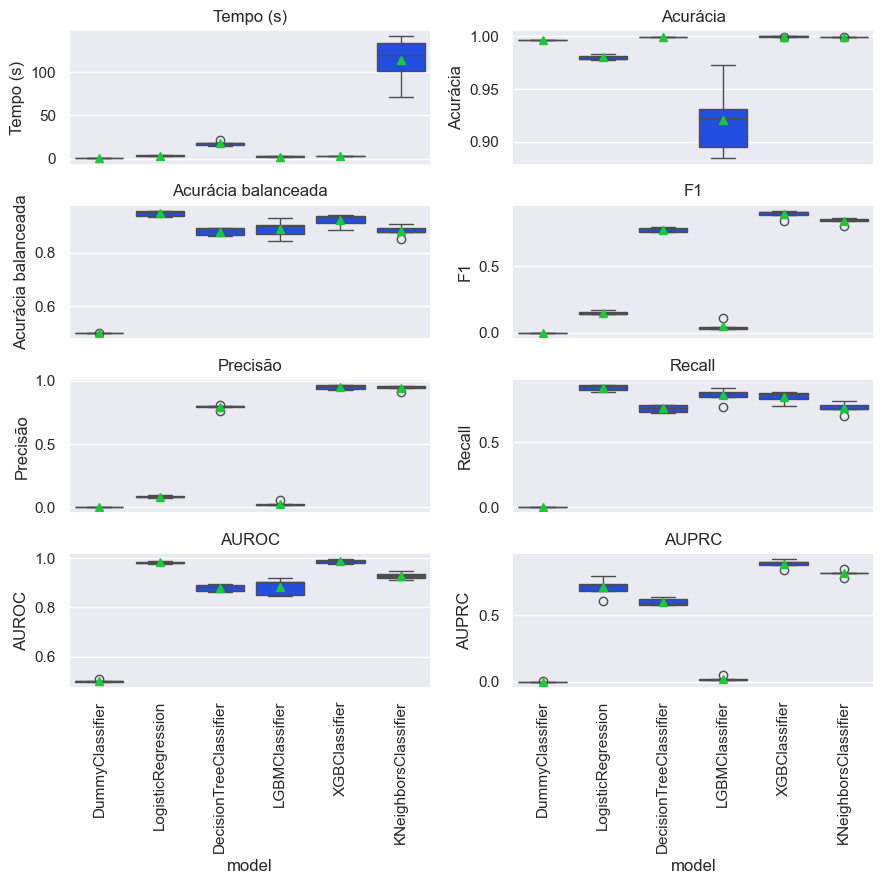

In [12]:
plot_comparar_metricas_modelos(df_resultados)

In [13]:
classificadores["XGBClassifier"]

{'preprocessor': None,
 'classificador': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=-1,
               num_parallel_tree=None, random_state=42, ...)}

In [14]:
treinar_e_validar_modelo_classificacao(X, y, kf, **classificadores["XGBClassifier"])

{'fit_time': array([2.90333176, 2.84913826, 2.82308125, 2.82611656, 2.96434593]),
 'score_time': array([0.22403073, 0.22884464, 0.19260716, 0.22786331, 0.20391035]),
 'test_accuracy': array([0.99945436, 0.99966872, 0.99970769, 0.99961026, 0.99966872]),
 'test_balanced_accuracy': array([0.88769653, 0.94381898, 0.93874622, 0.91411213, 0.93430438]),
 'test_f1': array([0.84444444, 0.91099476, 0.9197861 , 0.89130435, 0.91005291]),
 'test_precision': array([0.92682927, 0.93548387, 0.96629213, 0.96470588, 0.95555556]),
 'test_recall': array([0.7755102 , 0.8877551 , 0.87755102, 0.82828283, 0.86868687]),
 'test_roc_auc': array([0.97754795, 0.99096101, 0.98851886, 0.97993978, 0.99449895]),
 'test_average_precision': array([0.84433049, 0.90305055, 0.89986844, 0.88100103, 0.92162321])}

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, stratify=y)

In [16]:
clf = classificadores["XGBClassifier"]["classificador"]
clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [17]:
perm_imp = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring="average_precision")
ordem = perm_imp.importances_mean.argsort()

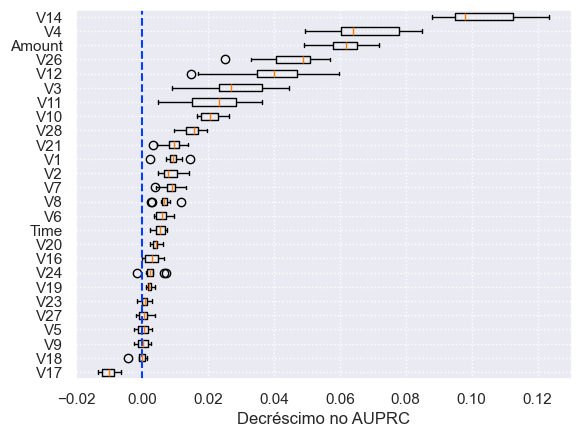

In [18]:
fig, ax = plt.subplots()

ax.boxplot(perm_imp.importances[ordem].T, vert=False, tick_labels=X.columns[ordem])
ax.axvline(x=0, linestyle="--")
ax.set_xlabel("Decréscimo no AUPRC")
ax.grid(True, linestyle=":")

plt.show()

In [19]:
perm_imp.importances_mean

array([ 0.00527042,  0.00928424,  0.00870414,  0.02871306,  0.06841606,
        0.00044666,  0.00616417,  0.00869138,  0.00665531,  0.00021158,
        0.0207063 ,  0.02268825,  0.03889337,  0.10351298,  0.00300705,
       -0.01019586, -0.00024938,  0.00235822,  0.00421469,  0.00933825,
        0.00068464,  0.00278895,  0.04534865,  0.0005824 ,  0.01521219,
        0.06118491])

In [20]:
X.columns[perm_imp.importances_mean < 0.01]

Index(['Time', 'V1', 'V2', 'V5', 'V6', 'V7', 'V8', 'V9', 'V16', 'V17', 'V18',
       'V19', 'V20', 'V21', 'V23', 'V24', 'V27'],
      dtype='object')

In [21]:
X = X.drop(columns=X.columns[perm_imp.importances_mean < 0.01])

X.columns

Index(['V3', 'V4', 'V10', 'V11', 'V12', 'V14', 'V26', 'V28', 'Amount'], dtype='object')

In [22]:
treinar_e_validar_modelo_classificacao(X, y, kf, **classificadores["XGBClassifier"])

{'fit_time': array([1.95751572, 1.72993875, 2.64991975, 6.1709621 , 3.03598881]),
 'score_time': array([0.22971249, 0.1998353 , 0.29196525, 0.23759341, 0.37102675]),
 'test_accuracy': array([0.99941539, 0.99962975, 0.99951282, 0.99953231, 0.99949334]),
 'test_balanced_accuracy': array([0.88258473, 0.93870717, 0.91827949, 0.91911382, 0.92413504]),
 'test_f1': array([0.83333333, 0.90052356, 0.86772487, 0.87368421, 0.86597938]),
 'test_precision': array([0.91463415, 0.92473118, 0.9010989 , 0.91208791, 0.88421053]),
 'test_recall': array([0.76530612, 0.87755102, 0.83673469, 0.83838384, 0.84848485]),
 'test_roc_auc': array([0.97385246, 0.97489323, 0.98426693, 0.97711579, 0.9926295 ]),
 'test_average_precision': array([0.82628555, 0.88727911, 0.88560336, 0.87943563, 0.88295909])}

In [23]:
param_grid = {
    "clf__max_depth": [3, 6, 10],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
    "clf__reg_lambda": [1, 2, 5],
    "clf__reg_alpha": [0, 0.5, 1]
}

In [24]:
clf = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=scale_pos_weight)

- use a função do grid_search_cv_classificador
- treine o grid_search
- verifique o best_params_, best_score_, best_estimator_
- crie uma lista comas mean_ para cada coluna no novo dataframe se o .startswith("test"), depois printe o cv_results_ de cada coluna com o best_index_ para cada coluna criada anteriormente
- plot um gráfico com o plot_importance com o best_estimator_, usando o weight como importance_type, depois repita isso, mas com o gain
